# Examples of aizawa equation discovery with EPDE framework

This notebook presents an overview of the evolutionary discovery of the burgers equation with the EPDE framework.

In [3]:
import numpy as np
import pandas as pd
import os
import sys
from typing import Union, Callable


import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D 

Add some necessary imports

In [4]:
import sys
sys.path.append('..')

import epde
from epde.interface.interface import EpdeSearch
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['text.usetex'] = False

SMALL_SIZE = 12
mpl.rc('font', size=SMALL_SIZE)
mpl.rc('axes', titlesize=SMALL_SIZE)

# Aizawa equation introduction.

Aizawa equation — a compact model describing a chaotic dynamical system in three-dimensional space, combining rotation and nonlinear damping in a single system of ordinary differential equations:

$$
\begin{cases}
\dfrac{dx}{dt} = (z - b)x - dy \\[4pt]
\dfrac{dy}{dt} = dx + (z - b)y \\[4pt]
\dfrac{dz}{dt} = c + az - \dfrac{z^3}{3} - (x^2+y^2)(1+ez) + fzx^3
\end{cases} \tag{1}
$$

where:

- $x(t), y(t), z(t)$ — the unknown coordinate functions (the position of a phase-space point at time $t$, whose trajectory traces out the attractor);
- $t$ — time;
- $a, b, c, d, e, f$ — the six control parameters, governing the shape and behavior of the system.

**Where it comes from.** The system is commonly attributed to Aizawa; however, no original publication by Aizawa describing exactly this form has been reliably located, and some sources suggest it may actually trace back to the Langford system. Regardless of attribution, it is widely used as a benchmark chaotic system due to the distinctive sphere-with-a-tube shape it produces.

**Example solution.** Unlike Burgers' equation, this system has no closed-form analytical solution — the nonlinear coupling between $x$, $y$, and $z$ (in particular the $z^3$, $(x^2+y^2)(1+ez)$, and $fzx^3$ terms) makes it analytically intractable. To generate data we will instead integrate the system numerically (e.g. with a Runge–Kutta scheme), starting from an initial condition near the origin:

$$
(x_0, y_0, z_0) = (0.1,\ 0,\ 0), \tag{2}
$$

using the standard parameter values

$$
a = 0.95,\quad b = 0.7,\quad c = 0.6,\quad d = 3.5,\quad e = 0.25,\quad f = 0.1. \tag{3}
$$

The resulting trajectory does not converge to a fixed point or a periodic orbit — instead it settles onto a bounded, non-repeating sphere-like surface with a tube-shaped structure piercing one of its axes, a hallmark of sensitive dependence on initial conditions characteristic of chaotic attractors.

Diagram below illustrate the approximate solution of aizawa equation with Range-Kutta method and default equation parametrs: a = 0.95, b = 0.7, c = 0.6, d = 3.5, e = 0.25, f = 0.1

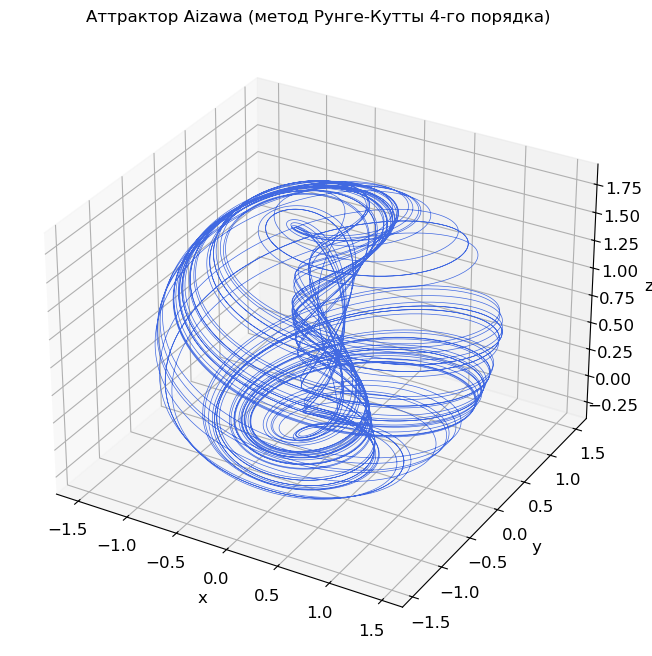

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # для 3D-графика

# Параметры системы Aizawa
a, b, c, d, e, f = 0.95, 0.7, 0.6, 3.5, 0.25, 0.1

# Правая часть системы (векторная функция)
def aizawa_rhs(state, a, b, c, d, e, f):
    x, y, z = state
    dx = (z - b) * x - d * y
    dy = d * x + (z - b) * y
    dz = c + a * z - (z**3) / 3 - (x**2 + y**2) * (1 + e * z) + f * z * x**3
    return np.array([dx, dy, dz])

# Один шаг метода Рунге-Кутты 4-го порядка
def rk4_step(state, dt, a, b, c, d, e, f):
    k1 = aizawa_rhs(state, a, b, c, d, e, f)
    k2 = aizawa_rhs(state + dt/2 * k1, a, b, c, d, e, f)
    k3 = aizawa_rhs(state + dt/2 * k2, a, b, c, d, e, f)
    k4 = aizawa_rhs(state + dt * k3, a, b, c, d, e, f)
    return state + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

# Параметры интегрирования
dt = 0.01
n_steps = 20000
state0 = np.array([0.1, 0.0, 0.0])  # начальные условия

# Массив для хранения траектории
trajectory = np.zeros((n_steps, 3))
trajectory[0] = state0

# Цикл интегрирования методом RK4
state = state0.copy()
for i in range(1, n_steps):
    state = rk4_step(state, dt, a, b, c, d, e, f)
    trajectory[i] = state

x_vals = trajectory[:, 0]
y_vals = trajectory[:, 1]
z_vals = trajectory[:, 2]

# Построение 3D-графика
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x_vals, y_vals, z_vals, lw=0.5, color='royalblue')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Аттрактор Aizawa (метод Рунге-Кутты 4-го порядка)')

plt.show()

Reading data(x, y, z) vectors from file 'aizawa.npz'

In [6]:
data = np.load("../projects/pic/data/aizawa/aizawa.npz")
t = data['t']
u = data['u']

x = u[..., 0]
y = u[..., 1]
z = u[..., 2]

In [7]:
epde_search_obj = EpdeSearch(use_solver = False, multiobjective_mode = True, use_pic = True, boundary = 15,
                             coordinate_tensors = (t,), verbose_params = {'show_iter_idx': True},
                             device='cpu')

setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x0000018D18335A90>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x0000018D18335A90>


Here you can see the explanation of each parametr in EpdeSearch creation:
   -  ``use_solver = False`` — skip the automatic PDE solver when scoring candidate equations; faster, less precise fitness estimate
   - ``multiobjective_mode = True`` — run MOEADD multi-objective search: Pareto front by Discrepancy (quality) + Instability
   - ``use_pic = True`` — define second pareto axis = Instability
   - ``boundary = 15`` — ignore this many grid points from each edge of the domain when computing derivatives
   - ``coordinate_tensors = (t, )`` — grid coordinate tensors (from np.meshgrid) matching the data array
   - ``device = 'cpu'`` — device for torch computations

In [8]:
epde_search_obj.set_preprocessor(default_preprocessor_type='FD',
                                     preprocessor_kwargs={})

popsize = 16
epde_search_obj.set_moeadd_params(population_size=popsize, training_epochs = 2)


In the cell above we define data preprocessor settings( preprocessing without data smoothing, finite derive calculation).
Additional parameters will be population size and number of optimziation epochs: ``training_epochs = 50``.

In [9]:
factors_max_number = {'factors_num': [1, 2], 'probas' : [0.8, 0.2]}

epde_search_obj.fit(data=[x, y, z], variable_names=['x', 'y', 'z'], max_deriv_order=(1,),
                    equation_terms_max_number=7, data_fun_pow=3, additional_tokens=[],
                    equation_factors_max_number=factors_max_number)



Deriv orders after definition [[0]]
initial_shape (120,) derivs_tensor.shape (120, 1)
Size of linked labels is 2
Deriv orders after definition [[0]]
initial_shape (120,) derivs_tensor.shape (120, 1)
Size of linked labels is 4
Deriv orders after definition [[0]]
initial_shape (120,) derivs_tensor.shape (120, 1)
Size of linked labels is 6
The cardinality of defined token pool is [1 1 1 1 1 1]
Among them, the pool contains [1 1 1 1 1 1]
self.vars_demand_equation {'y', 'z', 'x'}
best_obj 6

========== Initial population ==========
[2.11758368e-01 2.00890696e-01 9.76147448e-01 5.07734121e-04
 5.04285178e-04 1.55098250e-01]
[2.11758368e-01 2.00890696e-01 9.45871023e-01 5.07734121e-04
 5.04285178e-04 1.28152523e-01]
[2.11758368e-01 9.43710508e-01 9.91736699e-01 5.07734121e-04
 2.27174076e-01 1.73835576e-01]
[0.21175837 0.2008907  0.08660708 0.00050773 0.00050429 0.00452915]
[9.45871023e-01 2.00890696e-01 9.76147448e-01 1.28152523e-01
 5.04285178e-04 1.55098250e-01]
[3.50430031e-01 2.00890696e

Here you can see the explanation of each parametr in fit method:
 - argument ``data`` desctibes array of target variable(u)
 - argument ``variable_names`` sets name of target variable
 - argument ``max_deriv_order`` sets the highest order of derivatives, that can be used in equation search
- number of terms, accepted into the structure before regularization is regulated by argument ``equation_terms_max_number``
- argument ``equation_factors_max_number`` defines number of terms in the term can be set as integer (in this case, the number of factors for the particular term is selected from a uniform distribution
- argument ``additional_tokens`` sets tokens, hat would be used to construct the equations among the main variables and their derivatives
- argument ``data_fun_pow`` describes maximum power of token
Factors_max_number dictionary explanation
- argument ``factor_nums`` defines possible powers of factors in term
- argument ``probas`` defines probability distribution between factor_nums values
In our case factors with first pow appears in equation with 0.8 probability and second-pow factors appears with 0.2 probability

The discovered equations can be accessed with ``EpdeSearch.equations()`` method. If the ``only_print = True``, than the equations will be printed in their text forms. 

Otherwise, they will be return: if the followup argument ``only_str`` is ``True``, than the equations are returned only in their symbolic string-form. If ``only_str = False``, than the equation in its program implementation ``epde.structure.main_structures.SoEq`` are returned.

Additional parametr ``num = 3`` define number of poretto-levels for printing

In [11]:
epde_search_obj.equations(only_print=True, num = 5)



0-th non-dominated level


 / -3.5428025489257857 * y{power: 1.0} + 0.05504605333458065 * z{power: 3.0} * dy/dx0{power: 1.0} + 0.0 = dx/dx0{power: 1.0}
 | 3.466582125456683 * x{power: 1.0} + 0.0 = dy/dx0{power: 1.0}
 \ -0.31507703775686646 * z{power: 3.0} + -1.2059702651128923 * y{power: 2.0} + 0.8208995589516282 * z{power: 1.0} + -1.149408522178047 * x{power: 2.0} + 0.7233542817413356 = dz/dx0{power: 1.0}
{'max_terms_number': {'optimizable': False, 'value': 7}, 'max_factors_in_term': {'optimizable': False, 'value': {'factors_num': [1, 2], 'probas': [0.8, 0.2]}}, ('sparsity', 'y'): {'optimizable': True, 'value': np.float64(0.00034116029600609953)}, ('sparsity', 'z'): {'optimizable': True, 'value': np.float64(1.295720045017054)}, ('sparsity', 'x'): {'optimizable': True, 'value': np.float64(0.0001103718467233881)}} , with objective function values of [0.12473345 0.2008907  0.0897124  0.01014193 0.00050429 0.00572903] 

 / -3.4621395648953177 * y{power: 1.0} + 0.0 = dx/dx0{power: 1.0}
 

**Resulting Equation.**

Running EPDE on the Aizawa trajectory yields, for the best Pareto-front candidate:

$$
\frac{dx}{dt} = -3.4621 \cdot y, \qquad \frac{dy}{dt} = 3.4666 \cdot x
$$

This matches the linear rotational part of the true system, $dx/dt = (z-b)x - dy$, $dy/dt = dx + (z-b)y$: the recovered coupling coefficient ($\approx 3.46$–$3.55$) is close to the reference $d = 3.5$, though the $(z-b)$ modulation term is missing.

For $z$, the algorithm did not recover the expected form

$$
\frac{dz}{dt} = c + az - \frac{z^3}{3} - (x^2+y^2)(1+ez) + fzx^3,
$$


Overall: a good approximation of the (x, y) rotational subsystem, but a poor and structurally inaccurate one for the nonlinear z-dynamic, also results will improve with increasing num_epochs parametr

We can use visual analysis of the Pareto-optimal set of candidate equations, placed in the complexity-quality criteria space, to select the optimal equation. Method ``EpdeSearch.visualize_solutions()`` illustrates the first non-dominated set of solutions (i.e. Pareto frontier).

In [14]:
epde_search_obj.visualize_solutions()

ValueError: 
\frac{\partial x_}{\partial x0} = -3.543y + 5.505\cdot 10^{-2} \left(z\right)^{3.0} \cdot \frac{\partial y}{\partial x_0} + 0.0
                 ^
ParseSyntaxException: Expected {accent | symbol | function | operatorname | group | frac | dfrac | binom | genfrac | overset | underset | sqrt | overline | text | boldsymbol | substack}, found '}'  (at char 17), (line:1, col:18)